## Start by defining constants and primary field

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.special import ellipk, ellipe
from scipy.signal import fftconvolve
import time
from joblib import Parallel, delayed
import os


mu_0 = 4.0 * np.pi * 1e-7
eps0 = 8.8541878128e-12

f = 1.0e6
omega = 2.0 * np.pi * f

I_coil = 1.0       
a_coil = 1.5e-2    
z0 = 1.0e-2   

def Aphi_coil(rho, z, a, I):

    rho = np.asarray(rho)
    A_phi = np.zeros_like(rho)
    
    mask = rho > 1e-12
    rho_m = rho[mask]
    
    denom = a**2 + rho_m**2 + z**2 + 2*a*rho_m
    k2 = 4*a*rho_m / denom
    
    K = ellipk(k2)
    E = ellipe(k2)
    
    factor = ((2 - k2)*K - 2*E) / k2
    
    A_phi[mask] = (mu_0 * I * a / np.pi) * factor / np.sqrt(denom)
    
    return A_phi

## Create sample

In [3]:
Lx, Ly = 0.06, 0.06
Nx, Ny = 100, 100
dx, dy = Lx / Nx, Ly / Ny
h_thickness = dx

voxel_area = dx * dy

# Vectors with the center of each voxel
x = np.linspace(-Lx/2 + dx/2, Lx/2 - dx/2, Nx)
y = np.linspace(-Ly/2 + dy/2, Ly/2 - dy/2, Ny)

# Mesh
X, Y = np.meshgrid(x, y, indexing = "ij")

## Evaluate primary field in the sample

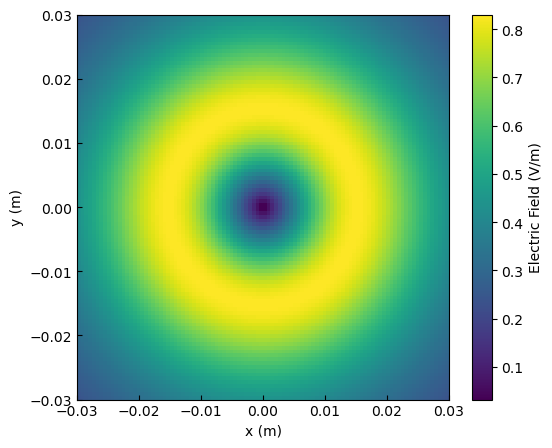

In [4]:
R = np.sqrt(X**2 + Y**2)
Phi = np.arctan2(Y, X)

A_phi = Aphi_coil(R, z0, a_coil, I_coil)
E_phi = -1j*omega*A_phi

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.pcolormesh(X, Y, np.abs(E_phi), shading='auto', cmap='viridis')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
fig.colorbar(im, ax=ax, label='Electric Field (V/m)')

ax.tick_params(direction='in')

### We start by computing the first partial correction for the scalar expansion. We create a function that returns, the charge density, the scalar potential and the electric field correction to first order.

In [5]:
def partial_correction(E1x, E1y, sigma, dx, dy, h_thickness = 0.01):
    
    log_sigma = np.log(sigma)
    dlogsig_dx = np.gradient(log_sigma, dx, axis=0) 
    dlogsig_dy = np.gradient(log_sigma, dy, axis=1)

    rho_eps0 = -(E1x * dlogsig_dx + E1y * dlogsig_dy)

    # Coulomb kernel
    Nx, Ny = sigma.shape
    kx = np.arange(-Nx+1, Nx) * dx
    ky = np.arange(-Ny+1, Ny) * dy
    KX, KY = np.meshgrid(kx, ky, indexing="ij") # Mismo indexing

    R_kernel = np.sqrt(KX**2 + KY**2 + (h_thickness/2.0)**2)
    kernel_coulomb = 1.0 / R_kernel

    # Convolution
    V2 = (h_thickness / (4.0 * np.pi)) * fftconvolve(rho_eps0, kernel_coulomb, mode='same') * dx * dy
    
    # Secondary field gradient
    dV2_dx = np.gradient(V2, dx, axis=0)
    dV2_dy = np.gradient(V2, dy, axis=1)

    delta_E2_x = -dV2_dx
    delta_E2_y = -dV2_dy

    return V2, delta_E2_x, delta_E2_y, rho_eps0

### For an arbitrary conductivity distribution we plot: The conductivity distribution in the sample, the charge density ($\rho/\epsilon_0$), and both the total electric field in the sample (corrected) and the first correction.

In [ ]:
A1x = -A_phi * np.sin(Phi)
A1y =  A_phi * np.cos(Phi)
A1x[R < 1e-15] = 0.0
A1y[R < 1e-15] = 0.0

E1x = -1j * omega * A1x
E1y = -1j * omega * A1y

# Add an arbitrary sigma distribution
sigma_healthy = 0.55   
sigma_anom = 0.2      

sigma_healthy_map = np.ones((Nx, Ny)) * 0.55
sigma_anom_map = np.ones((Nx, Ny)) * 0.55

# # Ellipse parameters
x_center_ellipse = 1e-2
y_center_ellipse = 0.0e-2
a_ellipse = 0.8e-2
b_ellipse = 1.2e-2

ellipse_mask = ((X-x_center_ellipse)**2/a_ellipse**2 + ((Y-y_center_ellipse)**2/b_ellipse**2)) <= 1

sigma_anom_map[ellipse_mask] = sigma_anom

# Partial correction
V2, delta_E2x, delta_E2y, rho_eps0 = partial_correction(E1x, E1y, sigma_anom_map, dx, dy)

E_total_x = E1x + delta_E2x 
E_total_y = E1y + delta_E2y


E_mag_total = np.sqrt(np.abs(E_total_x)**2 + np.abs(E_total_y)**2)
Partial_mag = np.sqrt(np.abs(delta_E2x)**2 + np.abs(delta_E2y)**2)

# Plotting
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 7))

im1 = ax1.pcolormesh(X, Y, sigma_anom_map, shading='auto', cmap='plasma')
ax1.set_title("Arbitrary Conductivity Distribution |$\sigma$|")
fig.colorbar(im1, ax=ax1, label = "S/m")

im2 = ax2.pcolormesh(X, Y, E_mag_total, shading='auto', cmap='viridis')
ax2.set_title("Total Electric Field |E|")
fig.colorbar(im2, ax=ax2, label = "V/m")
# ax2.streamplot(x, y, 
#                np.imag(E_total_x).T, np.imag(E_total_y).T, 
#                color='white',        
#                linewidth=1.0,        
#                density=1.5,          
#                arrowsize=1.5,        
#                arrowstyle='->')      

im3 = ax3.pcolormesh(X, Y, np.imag(rho_eps0), shading='auto', cmap='inferno')
ax3.set_title("Charge Density $\\rho/\\epsilon_0$")
fig.colorbar(im3, ax=ax3, label = "V/m$^2$")

im4 = ax4.pcolormesh(X, Y, Partial_mag, shading='auto', cmap='cividis')
ax4.set_title("Partial Correction")
fig.colorbar(im4, ax=ax4, label = "V/m")
# ax4.streamplot(x, y, np.imag(delta_E2x).T, np.imag(delta_E2y).T, 
#                color='white', linewidth=1, density=1.2, arrowsize=1.0)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.tick_params(direction="in")

plt.tight_layout()
plt.show()

## Geselowitz Theorem

In [1]:
# Precompute log-sigma gradients
log_sigma  = np.log(sigma_anom_map)
dlogsig_dx = np.gradient(log_sigma, dx, axis=0)
dlogsig_dy = np.gradient(log_sigma, dy, axis=1)

# Coulomb kernel (precomputed once)
kx_k = np.arange(-Nx + 1, Nx) * dx
ky_k = np.arange(-Ny + 1, Ny) * dy
KX_k, KY_k = np.meshgrid(kx_k, ky_k, indexing="ij")
kernel_coulomb = 1.0 / np.sqrt(KX_k**2 + KY_k**2 + (h_thickness / 2.0)**2)

# Volume element
dV = dx * dy * h_thickness

# Extended relative grid (precomputed once)
x_rel = np.arange(-(Nx - 1), Nx) * dx
y_rel = np.arange(-(Ny - 1), Ny) * dy
X_rel, Y_rel = np.meshgrid(x_rel, y_rel, indexing='ij')

R_rel_full = np.sqrt(X_rel**2 + Y_rel**2)
Phi_rel_full = np.arctan2(Y_rel, X_rel)

sin_phi_full = np.sin(Phi_rel_full)
cos_phi_full = np.cos(Phi_rel_full)

Aphi_tx_full = Aphi_coil(R_rel_full, z0, a_coil, I_coil)
Aphi_rx_full = Aphi_coil(R_rel_full, z0, 1e-2, I_coil)

def compute_row(i):
    Flux_row_anom = np.zeros(Ny, dtype=complex)
    Flux_row_healthy = np.zeros(Ny, dtype=complex)
    V_row_diff = np.zeros(Ny, dtype=complex)

    i0 = (Nx - 1) - i
    slx = slice(i0, i0 + Nx)

    for j in range(Ny):
        j0 = (Ny - 1) - j
        sly = slice(j0, j0 + Ny)

        A_phi_step = Aphi_tx_full[slx, sly]
        A_rec = Aphi_rx_full[slx, sly]
        sin_phi = sin_phi_full[slx, sly]
        cos_phi = cos_phi_full[slx, sly]

        # Primary field
        E1x = -1j * omega * (-A_phi_step * sin_phi)
        E1y = -1j * omega * ( A_phi_step * cos_phi)

        # Secondary field
        rho_eps0 = -(E1x * dlogsig_dx + E1y * dlogsig_dy)
        V2 = (h_thickness / (4.0 * np.pi)) * fftconvolve(rho_eps0, kernel_coulomb, mode='same') * dx * dy

        delta_E2x = -np.gradient(V2, dx, axis=0)
        delta_E2y = -np.gradient(V2, dy, axis=1)

        # Currents
        Jtot_x_anom = sigma_anom_map * (E1x + delta_E2x)
        Jtot_y_anom = sigma_anom_map * (E1y + delta_E2y)
        Jtot_x_healthy = sigma_healthy_map * E1x
        Jtot_y_healthy = sigma_healthy_map * E1y

        # Reciprocity
        Arec_x = -A_rec * sin_phi
        Arec_y =  A_rec * cos_phi

        # Flux & voltage
        flux_anom = np.sum(Jtot_x_anom * Arec_x + Jtot_y_anom * Arec_y) * dV
        flux_healthy = np.sum(Jtot_x_healthy * Arec_x + Jtot_y_healthy * Arec_y) * dV

        Flux_row_anom[j] = flux_anom
        Flux_row_healthy[j] = flux_healthy
        V_row_diff[j] = -1j * omega * (flux_anom - flux_healthy)

    return i, Flux_row_anom, Flux_row_healthy, V_row_diff

print(f"Starting scan with {Nx}x{Ny} points...")
start_time = time.time()

results = Parallel(n_jobs=-1)(
delayed(compute_row)(i) for i in range(Nx)
)

Flux_scan_anom = np.zeros((Nx, Ny), dtype=complex)
Flux_scan_healthy = np.zeros((Nx, Ny), dtype=complex)
V_rx_diff = np.zeros((Nx, Ny), dtype=complex)

for i, Flux_row_anom, Flux_row_healthy, V_row_diff_row in results:
    Flux_scan_anom[i, :] = Flux_row_anom
    Flux_scan_healthy[i, :] = Flux_row_healthy
    V_rx_diff[i, :] = V_row_diff_row

print(f"Escaneo completado en {time.time() - start_time:.4f} segundos.")

NameError: name 'np' is not defined

In [27]:
r_rec = 1e-2
Area_pickup = np.pi * r_rec**2

Bz_eq_anom = Flux_scan_anom / Area_pickup
Bz_eq_healthy = Flux_scan_healthy / Area_pickup
Bz_eq_diff = Bz_eq_anom - Bz_eq_healthy

# Save complex data
np.save("Bz_eq_anom.npy", Bz_eq_anom)
np.save("Bz_eq_healthy.npy", Bz_eq_healthy)
np.save("Bz_eq_diff.npy", Bz_eq_diff)

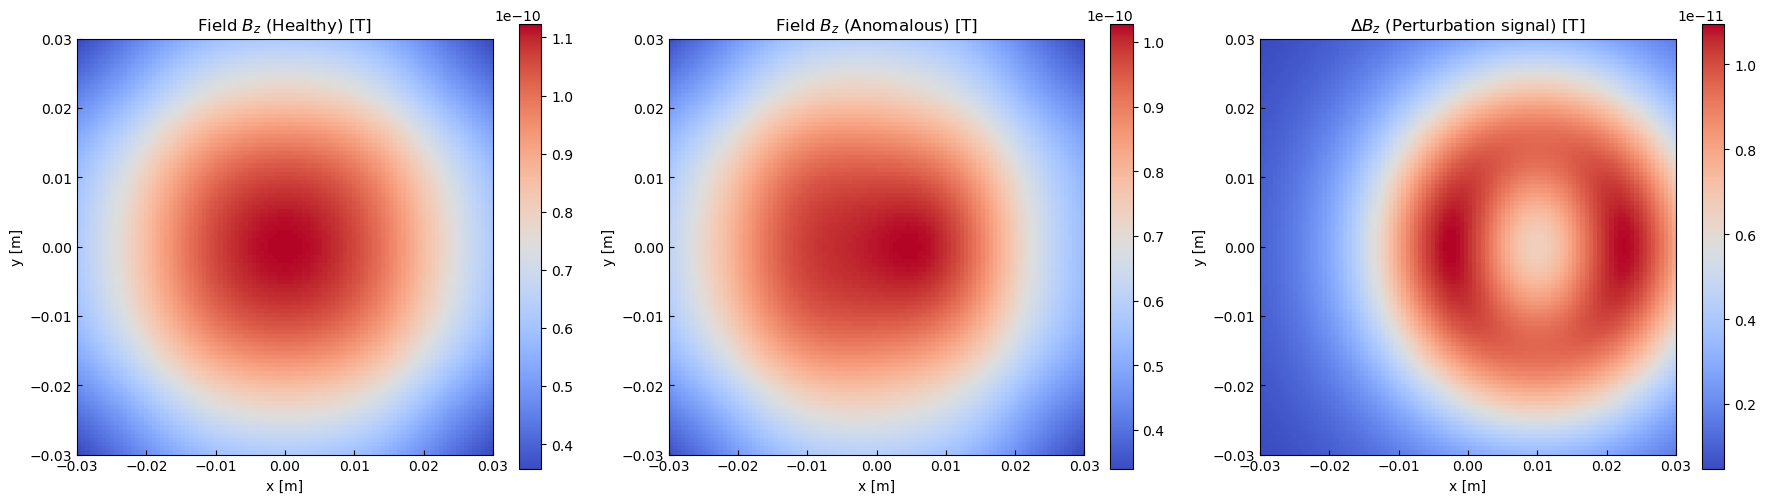

In [ ]:
Bz_eq_anom = np.load("Bz_eq_anom.npy")
Bz_eq_healthy = np.load("Bz_eq_healthy.npy")
Bz_eq_diff = np.load("Bz_eq_diff.npy")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im1 = axes[0].pcolormesh(X, Y, np.abs(Bz_eq_healthy), shading='auto', cmap='coolwarm')
axes[0].set_title("Field $B_z$ (Healthy) [T]")
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].pcolormesh(X, Y, np.abs(Bz_eq_anom), shading='auto', cmap='coolwarm')
axes[1].set_title("Field $B_z$ (Anomalous) [T]")
fig.colorbar(im2, ax=axes[1])

im3 = axes[2].pcolormesh(X, Y, np.abs(Bz_eq_diff), shading='auto', cmap='coolwarm')
axes[2].set_title("$\\Delta B_z$ (Perturbation signal) [T]")
fig.colorbar(im3, ax=axes[2])

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.tick_params(direction="in")
    
plt.tight_layout()
plt.show()